# Customer Churn Prediction

##### import the requiured libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

##### Load the dataset

In [2]:
df = pd.read_csv("customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### Check the various attributes of data like shape (rows and cols), Columns, datatypes

In [3]:
df.shape

(7043, 21)

In [4]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [5]:
# Checking the data types of all the columns
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
# Check the descriptive statistics of numeric variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


SeniorCitizen is actually a categorical hence the 25%-50%-75% distibution is not proper.  
75% customers have tenure less than 55 months,   
 Average Monthly charges are USD 64.76 whearas 25% customers pay more than USD 89.85 per month

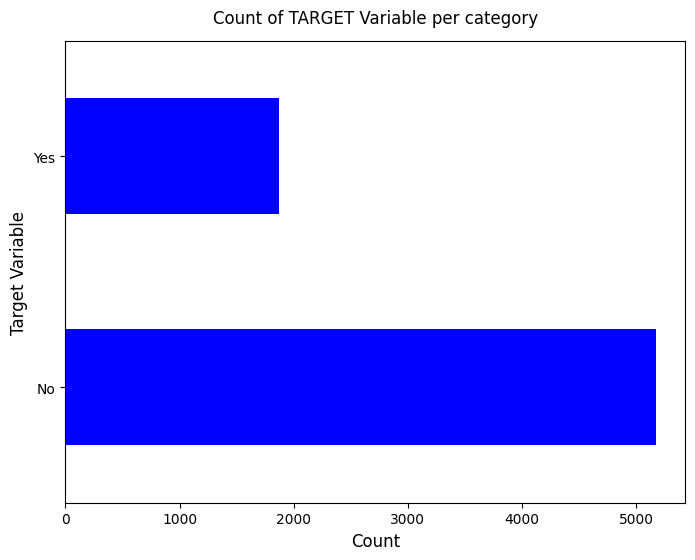

In [7]:
df['Churn'].value_counts().plot(kind='barh',figsize=(8,6),color="b")
plt.xlabel("Count",fontsize=12)
plt.ylabel("Target Variable",fontsize=12)
plt.title("Count of TARGET Variable per category", y=1.02)
plt.show()

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df['Churn'].value_counts()/len(df['Churn'])*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

- Data is highly imbalanced, ratio = 73.27
- So we analyse the data with other features while taking the target values separately to get some insights.

In [10]:
# Concise summary of the dataframe, as we have too many columns, we are using the verbose = True mode
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


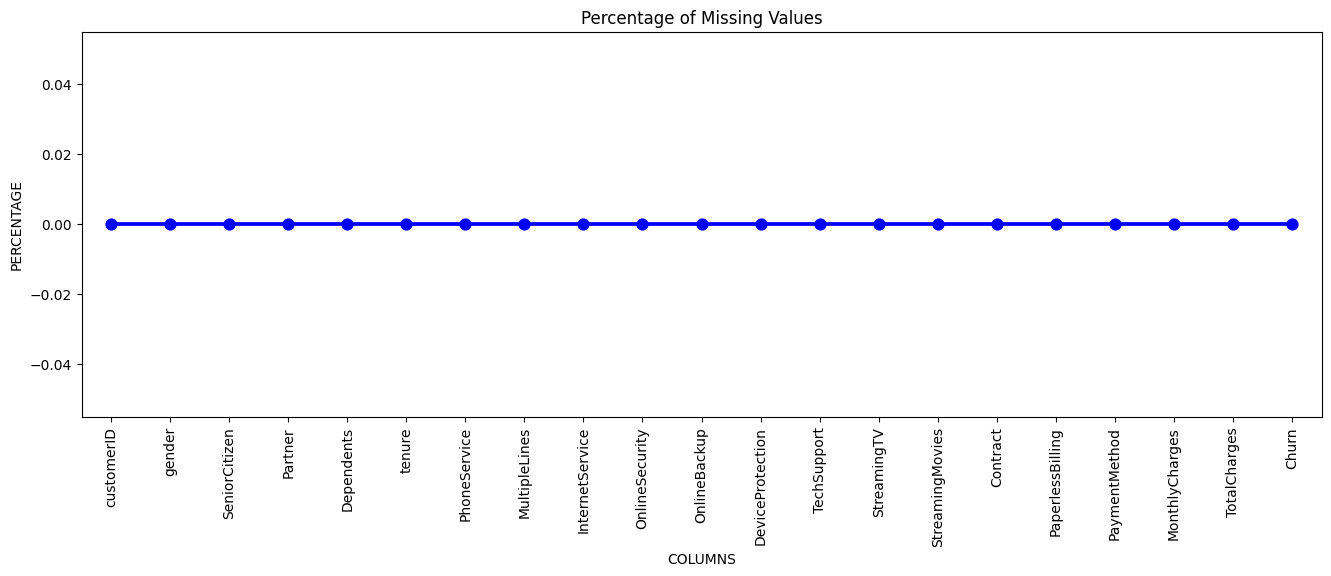

In [11]:
missing = pd.DataFrame(
    (df.isnull().sum() * 100 / df.shape[0])
).reset_index()

missing.columns = ['Column', 'Percentage']

plt.figure(figsize=(16,5))
ax = sns.pointplot(x='Column',y='Percentage',data=missing,color="b")
plt.xticks(rotation=90, fontsize=10)
plt.title("Percentage of Missing Values")
plt.ylabel("PERCENTAGE")
plt.xlabel("COLUMNS")
plt.show()

### Missing Data - intial intuition
- Here, we don't have any missing data.

- For features with less missing values- can use regression to predict the missing values or fill with the mean of the values present, depending on the feature.
- For features with very high number of missing values- it is better to drop those columns as they give very less insights on analysis.

## Data Cleaning
- Create a copy of base data for manipulation & processing

In [12]:
data = df.copy()

- Total Charges should be numeric amount. Let's convert it to numerical data type

In [13]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- As we can see there are 11 missing values in TotalCharges column. Let's check these records

In [14]:
data.loc[data['TotalCharges'].isnull() == True].sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## Missing value Treatment
- Since the % these records compared to total dataset is very low ie 0.15%, it is safe to ignore them from further processing.

In [15]:
# Removing missing values
data.dropna(how = 'any', inplace = True)

 Divide customers into bins based on tenure e.g for tenure < 12 months: assign a tenure group if 1-12, for tenure between 1 to 2 Yrs, tenure group of 13-24; so on.

In [16]:
# Get the max tenure
print(data['tenure'].max())   # 72

72


In [17]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]

data['tenure_group'] = pd.cut(data['tenure'], range(1, 80, 12), right=False, labels=labels)

In [18]:
data['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

#### Remove columns not required for processing

In [19]:
# drop column customerID and tenure
data.drop(columns= ['customerID','tenure'], axis=1, inplace=True)
data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


## Data Exploration
- Plot distribution of indivisual predictors by churn

### Univariate Analysis

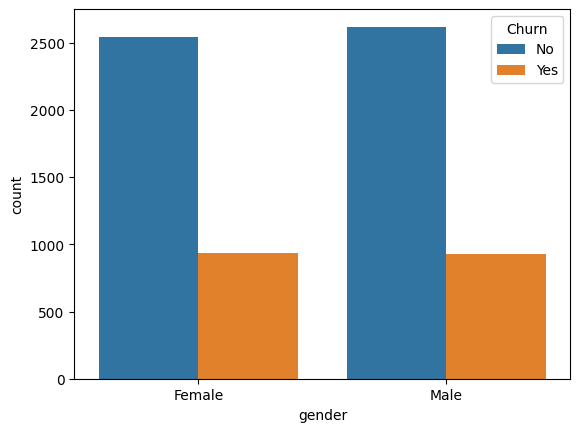

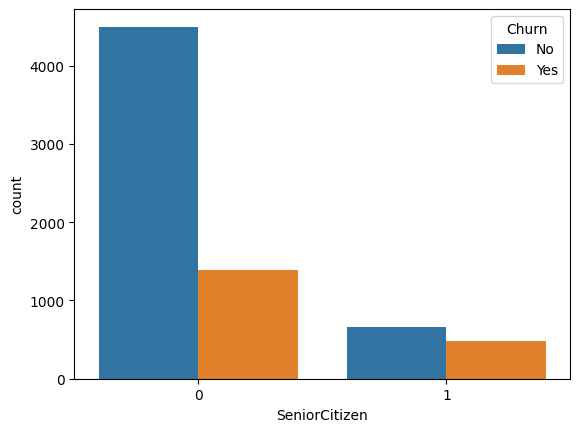

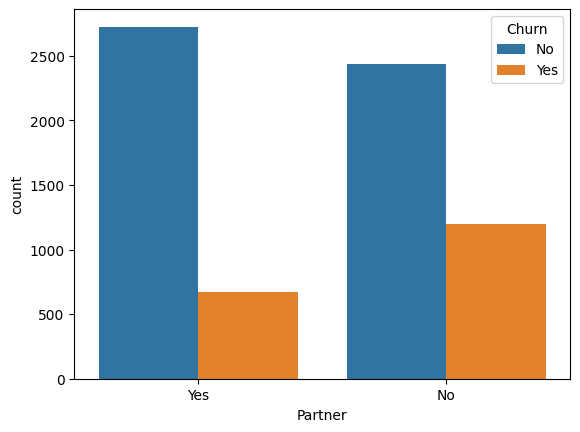

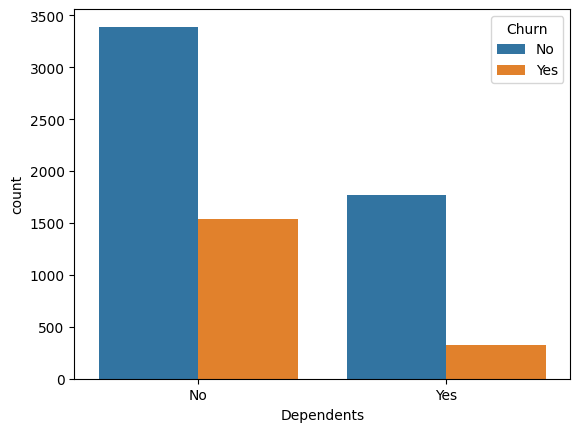

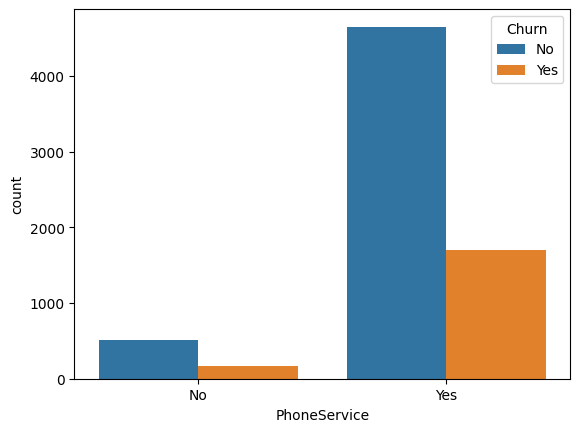

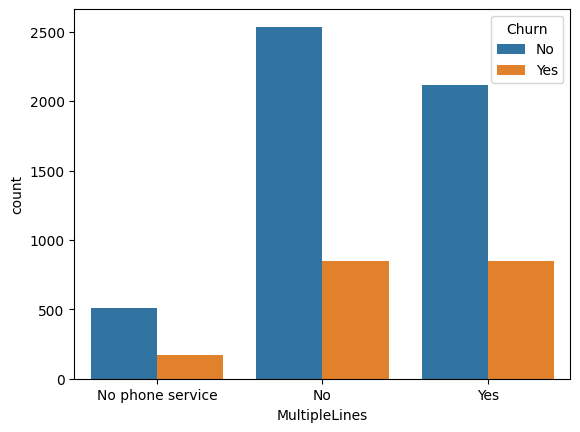

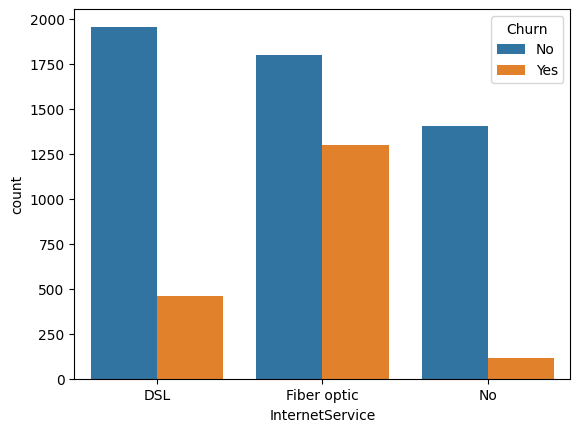

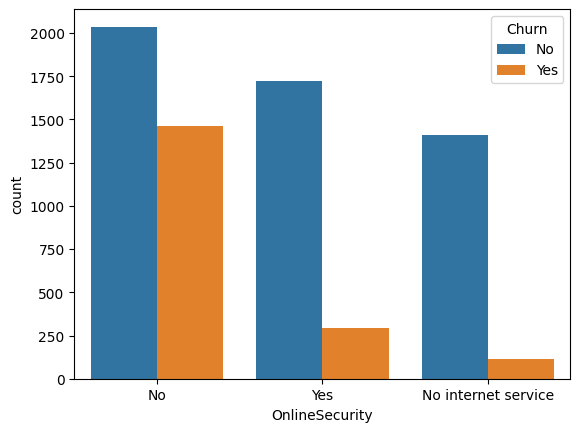

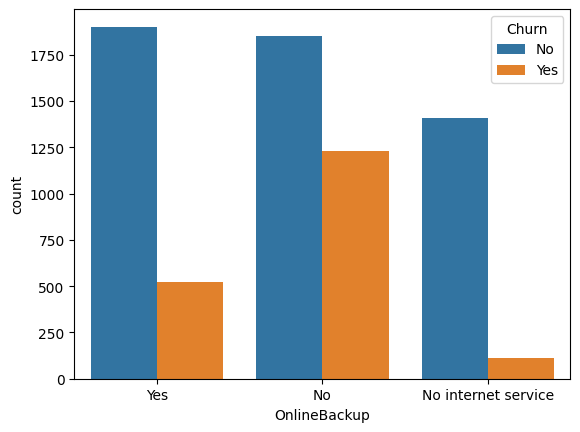

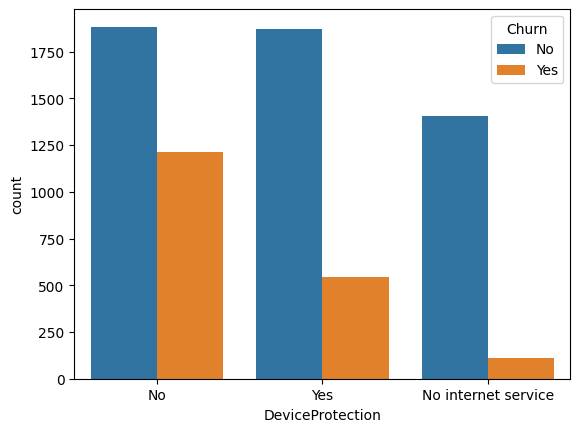

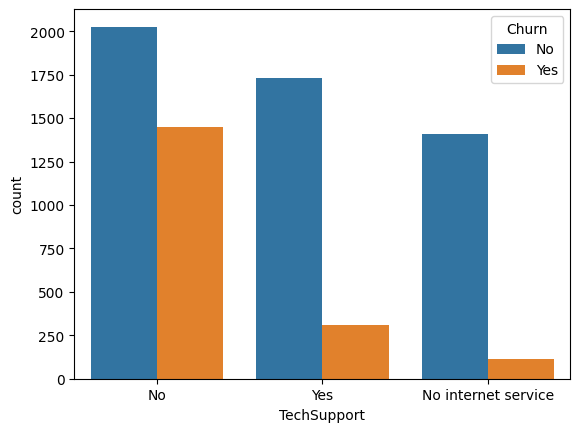

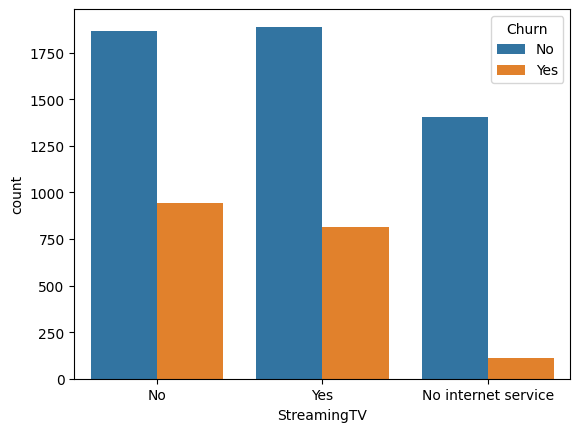

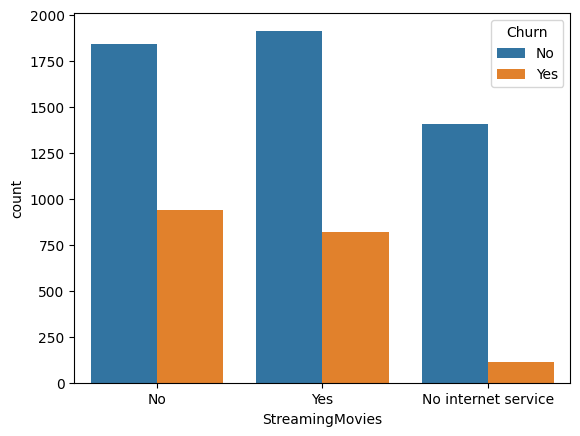

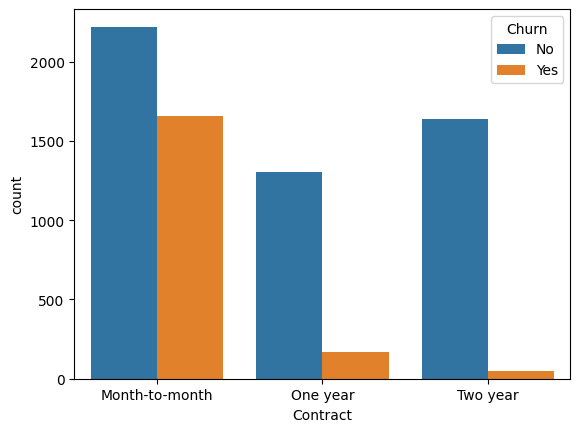

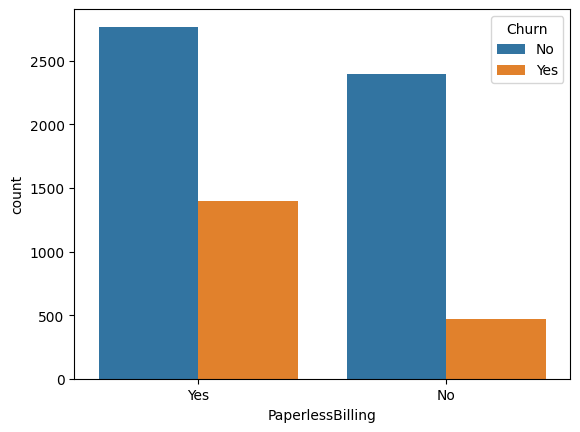

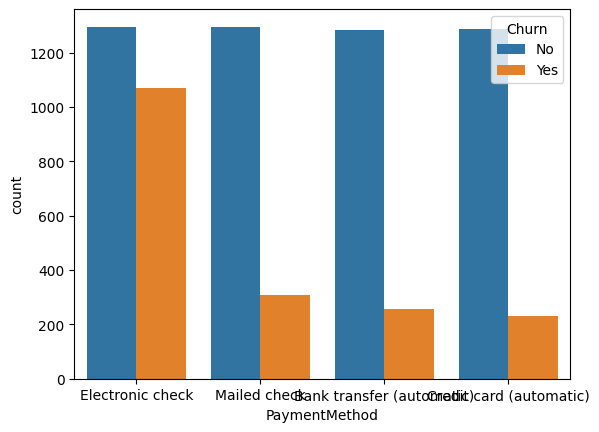

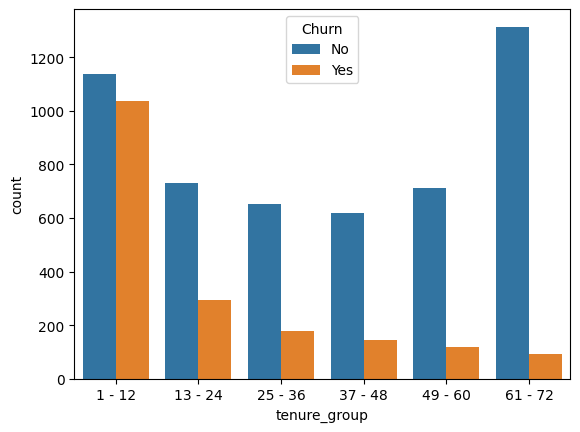

In [20]:
for i, predictor in enumerate(data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data=data, x=predictor, hue='Churn')

- Convert the target variable 'Churn' in a binary numeric variables i.e. Yes=1 ; No = 0

In [21]:
data['Churn'] = np.where(data['Churn'] == 'Yes',1,0)

In [22]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


- Convert all the categorical variables into dummy variables

In [23]:
data_dummies = pd.get_dummies(data,dtype=int)
data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


- Relationship between Monthly Charges and Total Charges

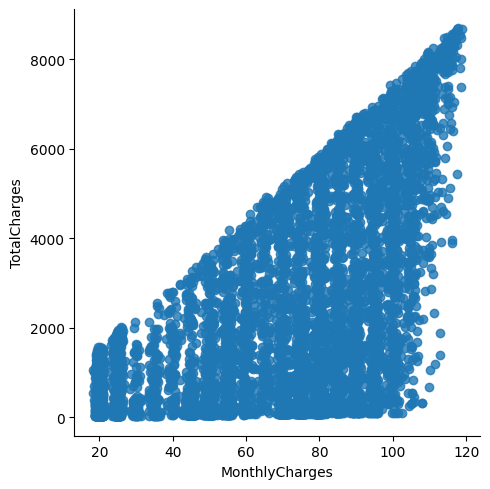

In [24]:
sns.lmplot(data=data_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False)   # Total Charges increase as Monthly Charges increase - as expected.
plt.show()

- Churn by Monthly Charges and Total Charges

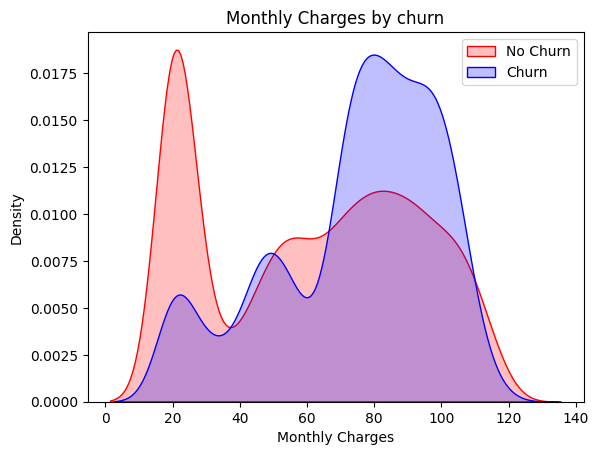

In [25]:
Mth = sns.kdeplot(data_dummies.MonthlyCharges[(data_dummies['Churn'] == 0)], color="Red", fill = True)
Mth = sns.kdeplot(data_dummies.MonthlyCharges[(data_dummies['Churn'] == 1)],color="Blue", fill = True)
Mth.legend(["No Churn", "Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly Charges by churn')
plt.show()

Insight: Churn is high when Monthly Charges are high

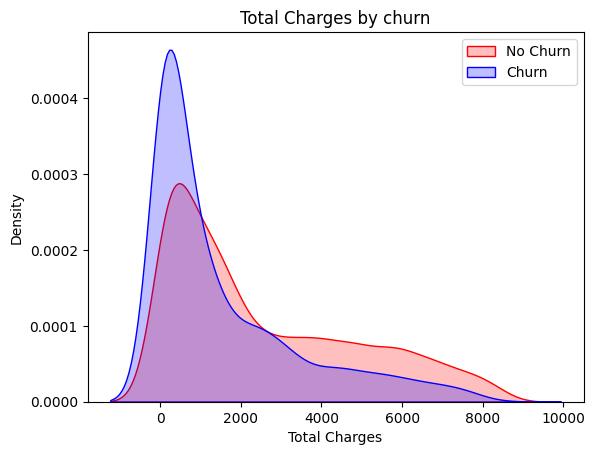

In [26]:
Mth = sns.kdeplot(data_dummies.TotalCharges[(data_dummies['Churn'] == 0)], color="Red", fill = True)
Mth = sns.kdeplot(data_dummies.TotalCharges[(data_dummies['Churn'] == 1)],color="Blue", fill = True)
Mth.legend(["No Churn", "Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Total Charges')
Mth.set_title('Total Charges by churn')
plt.show()

As higher Churn at lower Total Charges

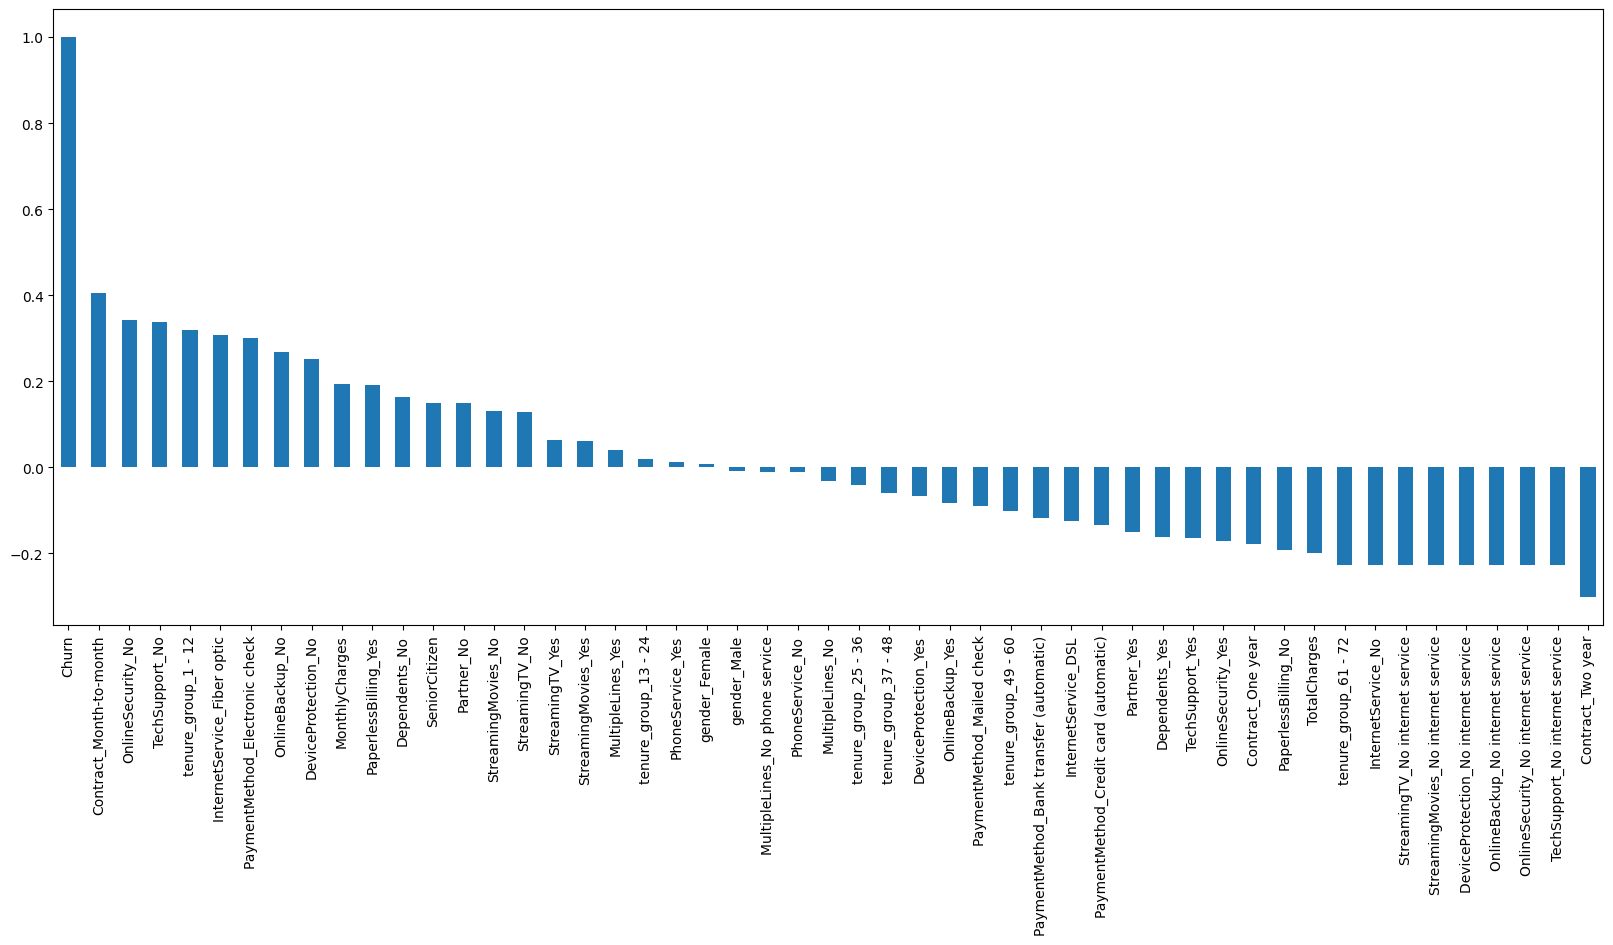

In [27]:
# Building a corelation of all predictors with 'Churn'
plt.figure(figsize=(20,8))
data_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')
plt.show()

Derived Insight
----------------

HIGH Churn seen in case of Month to Month contracts, No online security. No Tech Support, First year of subscription and Fibre Optics internet
LOW Churn is seens in case of Long term contracts, Subscriptions withouut internet service and The customers engaged for 5+ years
Factors like Gender, Avalability of PhoneService and of multiple lines have almost No impact on Churn
This is also evidetn from the Heatmap below

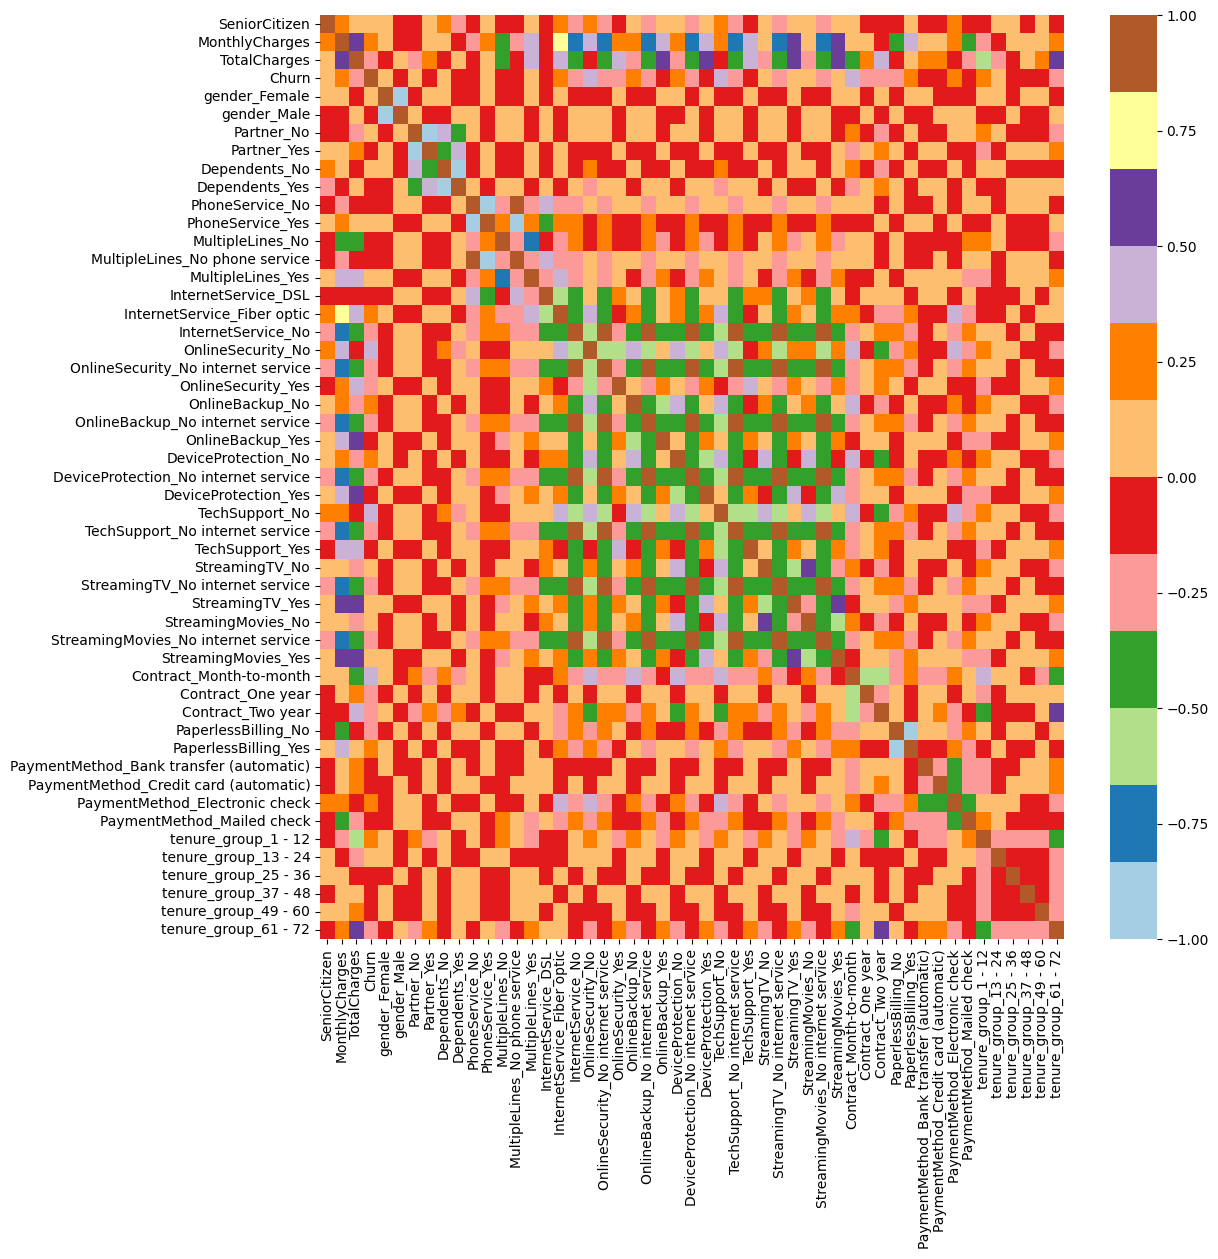

In [28]:
plt.figure(figsize=(12,12))
sns.heatmap(data_dummies.corr(), cmap="Paired")
plt.show()

## Bivariate Analysis

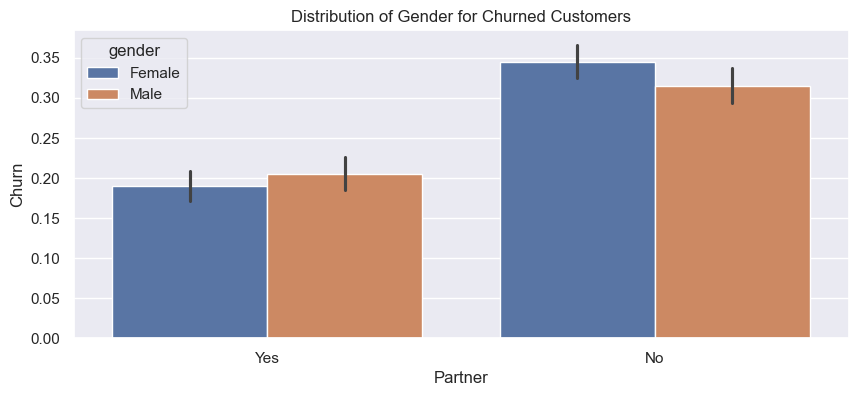

In [29]:
sns.set(style='darkgrid')
plt.figure(figsize=(10,4))
sns.barplot(x='Partner',y='Churn',data=data,hue='gender')
plt.title("Distribution of Gender for Churned Customers")
plt.show()

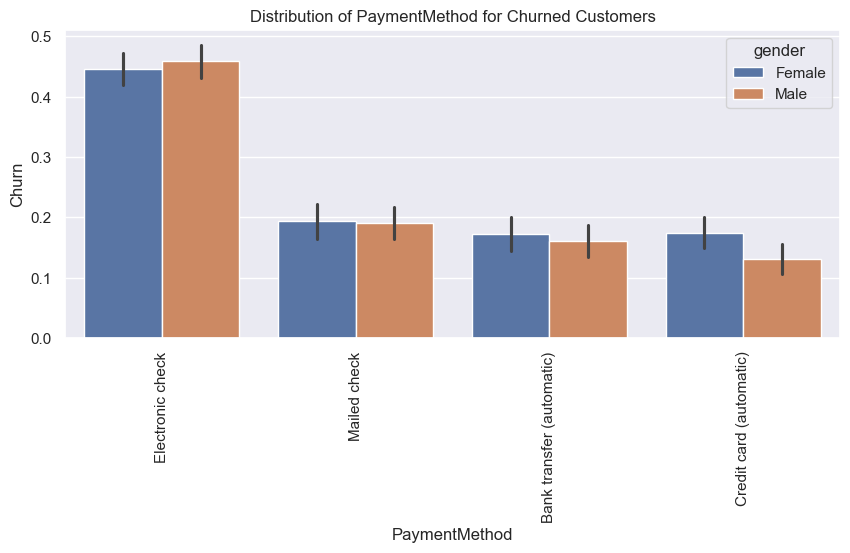

In [30]:
plt.figure(figsize=(10,4))
sns.barplot(x='PaymentMethod',y='Churn',data=data,hue='gender')
plt.title("Distribution of PaymentMethod for Churned Customers")
plt.xticks(rotation=90)
plt.show()

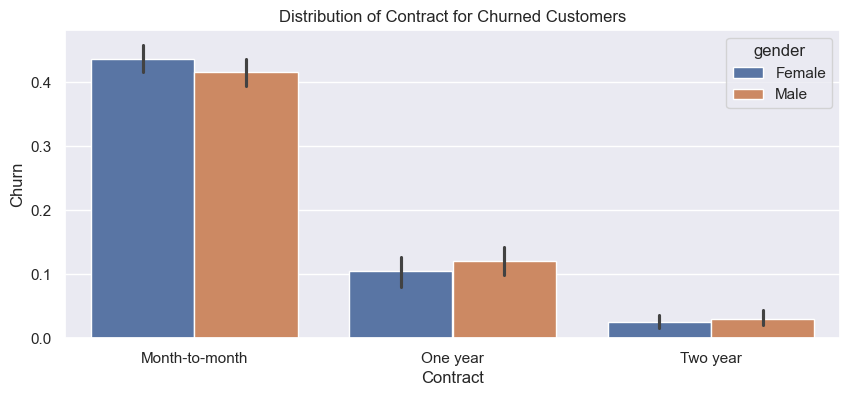

In [31]:
plt.figure(figsize=(10,4))
sns.barplot(x='Contract',y='Churn',data=data,hue='gender')
plt.title("Distribution of Contract for Churned Customers")
plt.show()

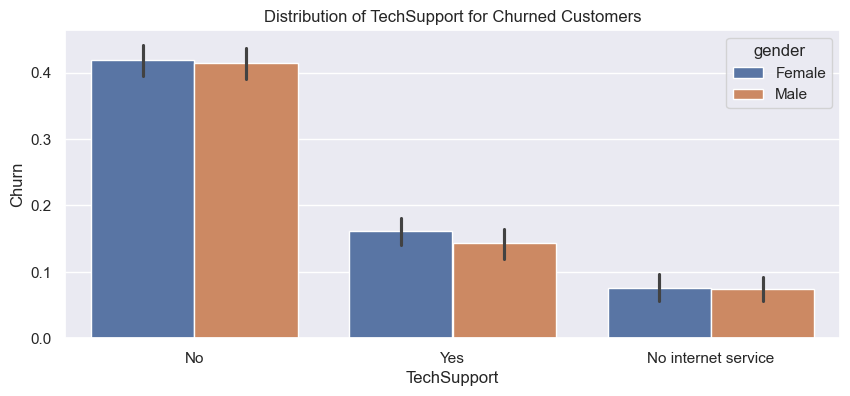

In [32]:
plt.figure(figsize=(10,4))
sns.barplot(x='TechSupport',y='Churn',data=data,hue='gender')
plt.title("Distribution of TechSupport for Churned Customers")
plt.show()

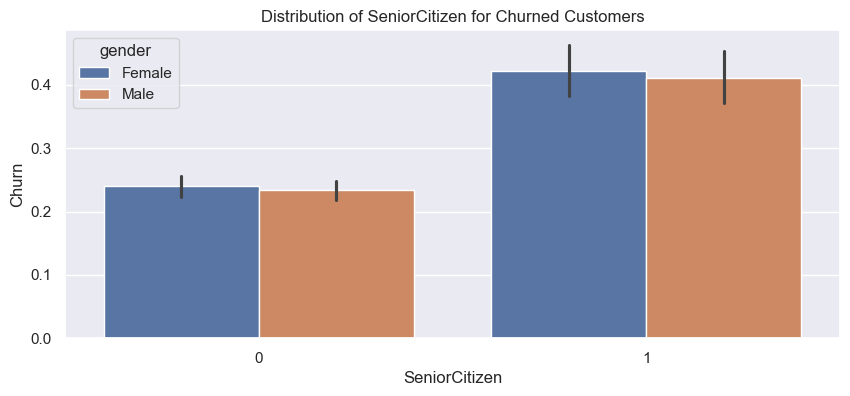

In [33]:
plt.figure(figsize=(10,4))
sns.barplot(x='SeniorCitizen',y='Churn',data=data,hue='gender')
plt.title("Distribution of SeniorCitizen for Churned Customers")
plt.show()

CONCLUSION
-----------
These are some of the quick insights from this exercise:

Electronic check medium are the highest churners
Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
No Online security, No Tech Support category are high churners
Non senior Citizens are high churners

# Model Building

In [34]:
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from imblearn.combine import SMOTEENN
# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [35]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [36]:
X = data.drop(columns='Churn')
y = data.Churn.copy()

print(X.shape, y.shape)

(7032, 19) (7032,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5625, 19) (5625,)
(1407, 19) (1407,)


In [38]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='O').columns.tolist()

print(num_cols)
print(cat_cols)

['SeniorCitizen', 'MonthlyCharges', 'TotalCharges']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [39]:
# Add in categorical column
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod','tenure_group']
num_cols = ['SeniorCitizen', 'MonthlyCharges', 'TotalCharges']

In [40]:
num_pipe = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

preprocessor.fit_transform(X_train)

array([[-0.43758982, -0.51862031, -0.08790784, ...,  1.        ,
         0.        ,  0.        ],
       [-0.43758982, -0.3744434 , -0.92128463, ...,  0.        ,
         0.        ,  0.        ],
       [-0.43758982,  0.43261589,  0.96378055, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.43758982,  0.5453059 , -0.65824663, ...,  0.        ,
         0.        ,  0.        ],
       [-0.43758982, -1.48974299, -0.56791079, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.28524509,  0.29672501, -0.35842967, ...,  0.        ,
         0.        ,  0.        ]], shape=(5625, 50))

In [41]:
models = {

    "logistic_regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "model__C": [0.1, 1, 10]
        }
    },

    "decision_tree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "model__max_depth": [3, 5, 10],
            "model__min_samples_split": [2, 5]
        }
    },

    "random_forest": {
        "model": RandomForestClassifier(),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10]
        }
    },

    "svm": {
        "model": SVC(),
        "params": {
            "model__C": [0.1, 1],
            "model__kernel": ['linear', 'rbf']
        }
    },

    "xgboost": {
        "model": XGBClassifier(eval_metric='logloss'),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.01, 0.1]
        }
    }
}

In [42]:
best_models = {}

for model_name, model_info in models.items():
    print(f"\n========== {model_name} ==========")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('model', model_info['model'])
    ])

    # GridSearchCV
    grid_search = GridSearchCV(estimator=pipeline, param_grid=model_info['params'], cv=5, scoring='f1', n_jobs=-1)

    # Fit model
    grid_search.fit(X_train, y_train)

    # Best model
    best_model = grid_search.best_estimator_

    # Prediction
    y_pred = best_model.predict(X_test)

    # Store best model
    best_models[model_name] = best_model

    # Results
    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Score:", grid_search.best_score_)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("Accuracy Score:", accuracy_score(y_test, y_pred))


========== logistic_regression ==========
Best Parameters: {'model__C': 10}
Best CV Score: 0.6056214019294881

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.61      0.74      1033
           1       0.44      0.86      0.59       374

    accuracy                           0.68      1407
   macro avg       0.68      0.74      0.66      1407
weighted avg       0.80      0.68      0.70      1407

Accuracy Score: 0.6773276474769012

========== decision_tree ==========
Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 2}
Best CV Score: 0.6055368756981185

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.64      0.75      1033
           1       0.45      0.79      0.57       374

    accuracy                           0.68      1407
   macro avg       0.67      0.72      0.66      1407
weighted avg       0.78      0.68      0.70      1407

Accurac

In [43]:
import joblib

# Save best xgboost pipeline
joblib.dump(best_models['xgboost'], 'xgboost_pipeline.pkl')

print("Model saved successfully")

Model saved successfully


In [44]:
import pandas as pd

# Random sample customer data
new_data = pd.DataFrame({

    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [89.85],
    'TotalCharges': [1080.50],
    'tenure_group': ['12-24 Month']

})

# Load saved model
import joblib

loaded_model = joblib.load('xgboost_pipeline.pkl')

# Prediction
prediction = loaded_model.predict(new_data)

# Probability
probability = loaded_model.predict_proba(new_data)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[0.06797117 0.93202883]]


In [45]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [ ]:
data.to_csv("churn.csv")